# Character Recognition using Multilayer Perceptron (MLP)

## Overview
This notebook implements a comprehensive character recognition system using a Multilayer Perceptron neural network with proper ML workflow including:
- Data Loading and Exploration
- Data Preprocessing and Feature Engineering
- Train/Test/Validation Split
- Model Building
- Training and Validation
- Evaluation and Performance Metrics
- Predictions on New Data

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
import sklearn

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

✓ All libraries imported successfully!
NumPy version: 2.3.1
Pandas version: 2.3.0
Scikit-learn version: 1.7.2


## Step 1: Data Loading and Exploration

In [2]:
# Load CSV file
data_path = '../data/english.csv'
df = pd.read_csv(data_path)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:")
print(df.describe())

DATASET OVERVIEW
Dataset shape: (3410, 2)

First few rows:
                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0
5  Img/img001-006.png     0
6  Img/img001-007.png     0
7  Img/img001-008.png     0
8  Img/img001-009.png     0
9  Img/img001-010.png     0

Data types:
image    object
label    object
dtype: object

Missing values:
image    0
label    0
dtype: int64

Basic statistics:
                     image label
count                 3410  3410
unique                3410    62
top     Img/img001-001.png     0
freq                     1    55


In [3]:
# Load and analyze images
def load_images_from_csv(df, img_dir='../data/', sample_size=None):
    """Load images from file paths in CSV and convert to arrays"""
    images = []
    labels = []
    failed_count = 0
    
    # Use sample if specified
    data_to_load = df.sample(n=min(sample_size, len(df))) if sample_size else df
    
    for idx, row in data_to_load.iterrows():
        try:
            # Construct full path
            img_path = os.path.join(img_dir, row['image'])
            
            # Load image and convert to grayscale
            img = Image.open(img_path).convert('L')
            
            # Convert to array and flatten
            img_array = np.array(img).flatten()
            
            images.append(img_array)
            labels.append(row['label'])
            
        except Exception as e:
            failed_count += 1
            if failed_count <= 5:  # Show first 5 errors
                print(f"Error loading {row['image']}: {str(e)}")
    
    print(f"\n✓ Successfully loaded {len(images)} images")
    print(f"✗ Failed to load {failed_count} images")
    
    return np.array(images), np.array(labels)

# Load sample images first to check dimensions
print("Loading sample of images...")
X_sample, y_sample = load_images_from_csv(df, sample_size=500)

print(f"\nImage Array Shape: {X_sample.shape}")
print(f"Label Array Shape: {y_sample.shape}")
print(f"Unique labels: {np.unique(y_sample)}")
print(f"Number of classes: {len(np.unique(y_sample))}")

Loading sample of images...

✓ Successfully loaded 500 images
✗ Failed to load 0 images

Image Array Shape: (500, 1080000)
Label Array Shape: (500,)
Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']
Number of classes: 62


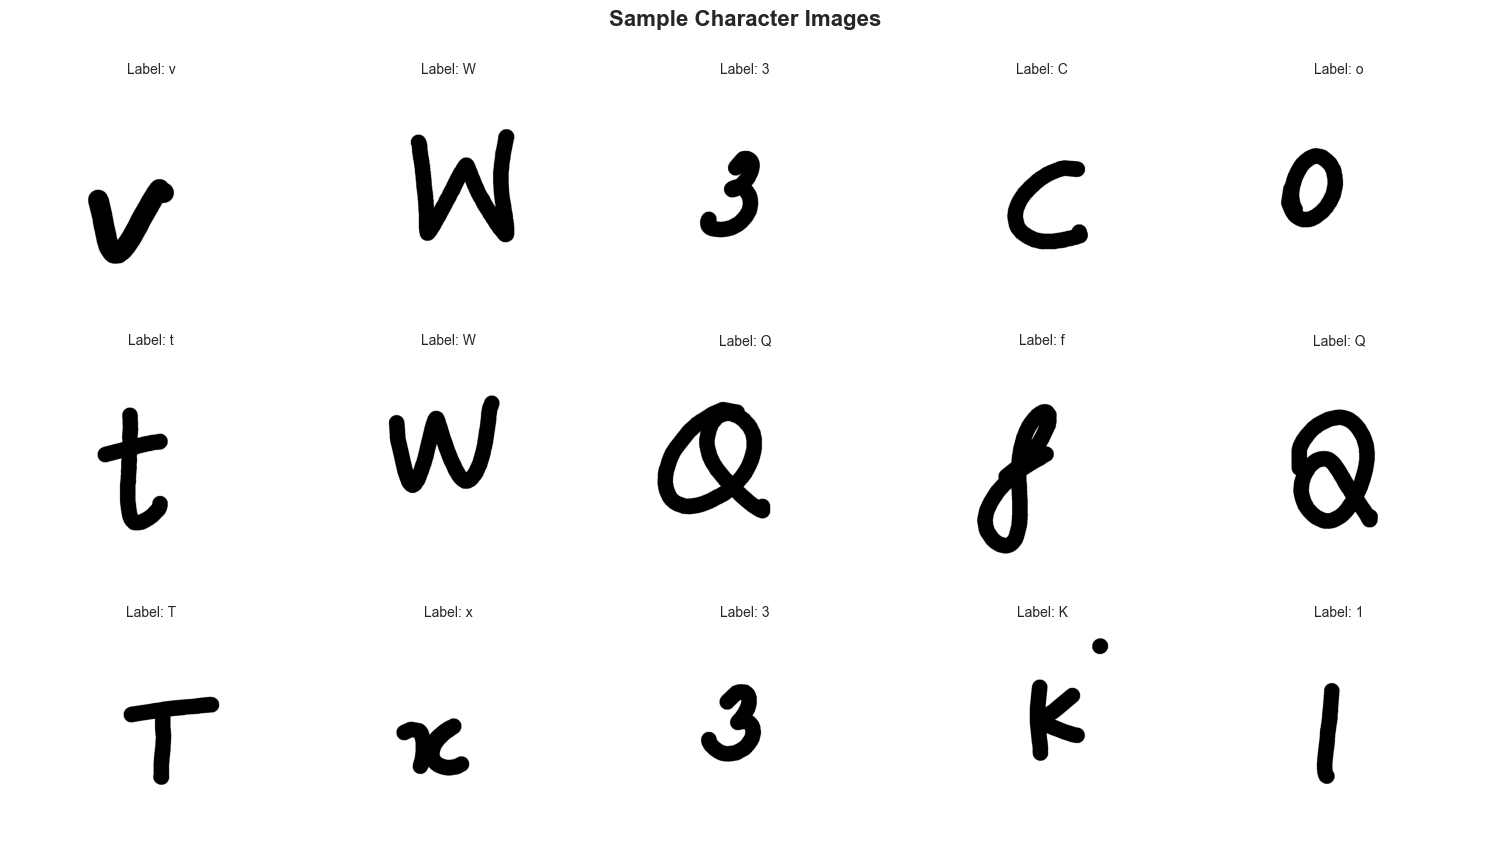

In [4]:
# Visualize sample images (load directly from file paths)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Character Images', fontsize=16, fontweight='bold')

sample_rows = df.sample(15, random_state=42).reset_index(drop=True)
for idx, row in sample_rows.iterrows():
    ax = axes[idx // 5, idx % 5]
    img_path = os.path.join('../data/', row['image'])
    img = Image.open(img_path).convert('L')
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {row['label']}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 2: Load Full Dataset and Preprocessing

In [5]:
# Load dataset and reduce dimensionality with IncrementalPCA
from sklearn.decomposition import IncrementalPCA

print("Loading dataset and fitting IncrementalPCA...")
img_dir = '../data/'
n_components = 64
batch_size = 64
print(f"Using n_components={n_components}, batch_size={batch_size}")

def load_image_batch(df_slice, img_dir):
    images = []
    for rel_path in df_slice['image']:
        img_path = os.path.join(img_dir, rel_path)
        img = Image.open(img_path).convert('L')
        img_array = np.array(img, dtype=np.float32).flatten()
        img_array /= 255.0
        images.append(img_array)
    return np.stack(images)

y_full = df['label'].values
num_samples = len(df)

pca = IncrementalPCA(n_components=n_components, batch_size=batch_size)

for start in range(0, num_samples, batch_size):
    end = min(start + batch_size, num_samples)
    X_batch = load_image_batch(df.iloc[start:end], img_dir)
    pca.partial_fit(X_batch)
    if end % 500 == 0 or end == num_samples:
        print(f"  PCA fit: {end}/{num_samples}")
    del X_batch

X_reduced = np.zeros((num_samples, n_components), dtype=np.float32)
for start in range(0, num_samples, batch_size):
    end = min(start + batch_size, num_samples)
    X_batch = load_image_batch(df.iloc[start:end], img_dir)
    X_reduced[start:end] = pca.transform(X_batch).astype(np.float32)
    if end % 500 == 0 or end == num_samples:
        print(f"  PCA transform: {end}/{num_samples}")
    del X_batch

X_full = X_reduced
print("\nPCA complete")
print(f"  Total samples: {X_full.shape[0]}")
print(f"  Features per sample: {X_full.shape[1]}")
print(f"  Unique classes: {len(np.unique(y_full))}")

Loading dataset and fitting IncrementalPCA...
Using n_components=64, batch_size=64
  PCA fit: 3410/3410
  PCA transform: 3410/3410

PCA complete
  Total samples: 3410
  Features per sample: 64
  Unique classes: 62


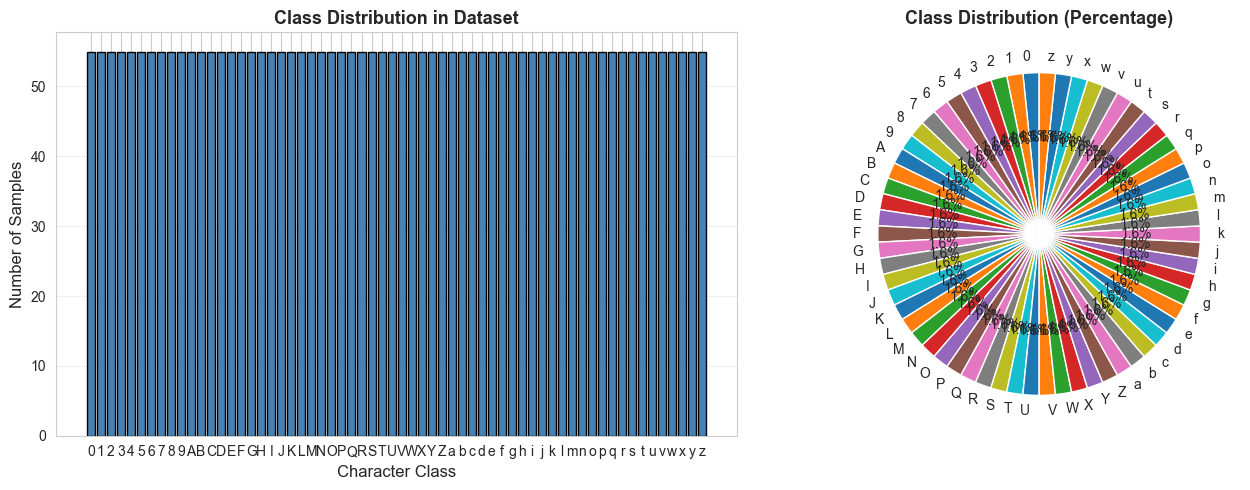

In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
unique_labels, class_counts = np.unique(y_full, return_counts=True)
axes[0].bar(unique_labels, class_counts, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Character Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Class Distribution in Dataset', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=unique_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Feature standardization after PCA
print("Standardizing PCA features...")
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_full)
print(f"After standardization: mean={X_normalized.mean():.4f}, std={X_normalized.std():.4f}")

Standardizing PCA features...
After standardization: mean=0.0000, std=1.0000


## Step 3: Train-Validation-Test Split

In [8]:
# Convert labels to numeric encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_full)

print("Label encoding:")
print(f"  Original labels: {np.unique(y_full)}")
print(f"  Encoded labels: {np.unique(y_encoded)}")
print(f"  Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"    {label} -> {i}")

# Split data: 70% train, 15% validation, 15% test
print("\n" + "-" * 60)
print("Splitting data into train, validation, and test sets...")
print("-" * 60)

idx_all = np.arange(len(X_normalized))

X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X_normalized, y_encoded, idx_all, test_size=0.30, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X_normalized)*100:.2f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_normalized)*100:.2f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X_normalized)*100:.2f}%)")
print(f"\nTotal: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} samples")

print(f"\nClass distribution check:")
for label_idx in np.unique(y_encoded):
    train_pct = np.sum(y_train == label_idx) / len(y_train) * 100
    val_pct = np.sum(y_val == label_idx) / len(y_val) * 100
    test_pct = np.sum(y_test == label_idx) / len(y_test) * 100
    orig_label = le.classes_[label_idx]
    if label_idx % 10 == 0:
        print(f"  Class {orig_label} ({label_idx}): Train={train_pct:.1f}%, Val={val_pct:.1f}%, Test={test_pct:.1f}%")

Label encoding:
  Original labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']
  Encoded labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61]
  Label mapping:
    0 -> 0
    1 -> 1
    2 -> 2
    3 -> 3
    4 -> 4
    5 -> 5
    6 -> 6
    7 -> 7
    8 -> 8
    9 -> 9
    A -> 10
    B -> 11
    C -> 12
    D -> 13
    E -> 14
    F -> 15
    G -> 16
    H -> 17
    I -> 18
    J -> 19
    K -> 20
    L -> 21
    M -> 22
    N -> 23
    O -> 24
    P -> 25
    Q -> 26
    R -> 27
    S -> 28
    T -> 29
    U -> 30
    V -> 31
    W -> 32
    X -> 33
    Y -> 34
    Z -> 35
    a -> 36
    b -> 37
    c -> 38
    d -> 39
    e -> 40
    f

## Step 4: Multilayer Perceptron Model Building

In [9]:
# Build Multilayer Perceptron Model
print("Building Multilayer Perceptron Model...")
print("=" * 60)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),    # Larger network to reduce underfitting
    max_iter=200,                          # More iterations for convergence
    batch_size=64,                         # Larger batch size for stability
    learning_rate='adaptive',              # Adaptive learning rate
    learning_rate_init=0.001,              # Initial learning rate
    activation='relu',                     # ReLU activation function
    solver='adam',                         # Adam optimizer
    alpha=1e-5,                            # L2 regularization (lighter)
    early_stopping=False,                  # Train fully (avoid premature stop)
    random_state=42,                       # For reproducibility
    verbose=1                              # Print progress
)

print("\nModel Configuration:")
print(f"  Hidden layers: {mlp_model.hidden_layer_sizes}")
print(f"  Activation function: {mlp_model.activation}")
print(f"  Solver: {mlp_model.solver}")
print(f"  Learning rate: {mlp_model.learning_rate_init}")
print(f"  Maximum iterations: {mlp_model.max_iter}")
print(f"  Early stopping: {mlp_model.early_stopping}")
print("=" * 60)

Building Multilayer Perceptron Model...

Model Configuration:
  Hidden layers: (512, 256, 128)
  Activation function: relu
  Solver: adam
  Learning rate: 0.001
  Maximum iterations: 200
  Early stopping: False


## Step 5: Model Training

In [10]:
import time

# Train the model
print("\nTraining Multilayer Perceptron Model...")
print("=" * 60)

start_time = time.time()

mlp_model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"\n✓ Training completed in {training_time:.2f} seconds")
print(f"  Iterations: {mlp_model.n_iter_}")
print(f"  Loss: {mlp_model.loss_:.6f}")
print(f"  Training accuracy: {mlp_model.score(X_train, y_train):.4f}")


Training Multilayer Perceptron Model...
Iteration 1, loss = 4.06367657
Iteration 2, loss = 3.35170887
Iteration 3, loss = 2.41593221
Iteration 4, loss = 1.81754880
Iteration 5, loss = 1.39413852
Iteration 6, loss = 1.11815994
Iteration 7, loss = 0.84230858
Iteration 8, loss = 0.61902517
Iteration 9, loss = 0.46818044
Iteration 10, loss = 0.35494745
Iteration 11, loss = 0.25401188
Iteration 12, loss = 0.18225964
Iteration 13, loss = 0.13478732
Iteration 14, loss = 0.10133415
Iteration 15, loss = 0.07861088
Iteration 16, loss = 0.06368038
Iteration 17, loss = 0.05177430
Iteration 18, loss = 0.04277129
Iteration 19, loss = 0.03234658
Iteration 20, loss = 0.02718342
Iteration 21, loss = 0.02360197
Iteration 22, loss = 0.02021481
Iteration 23, loss = 0.01947852
Iteration 24, loss = 0.01995484
Iteration 25, loss = 0.01654835
Iteration 26, loss = 0.01495016
Iteration 27, loss = 0.01200680
Iteration 28, loss = 0.01055880
Iteration 29, loss = 0.00988895
Iteration 30, loss = 0.01221368
Iteratio

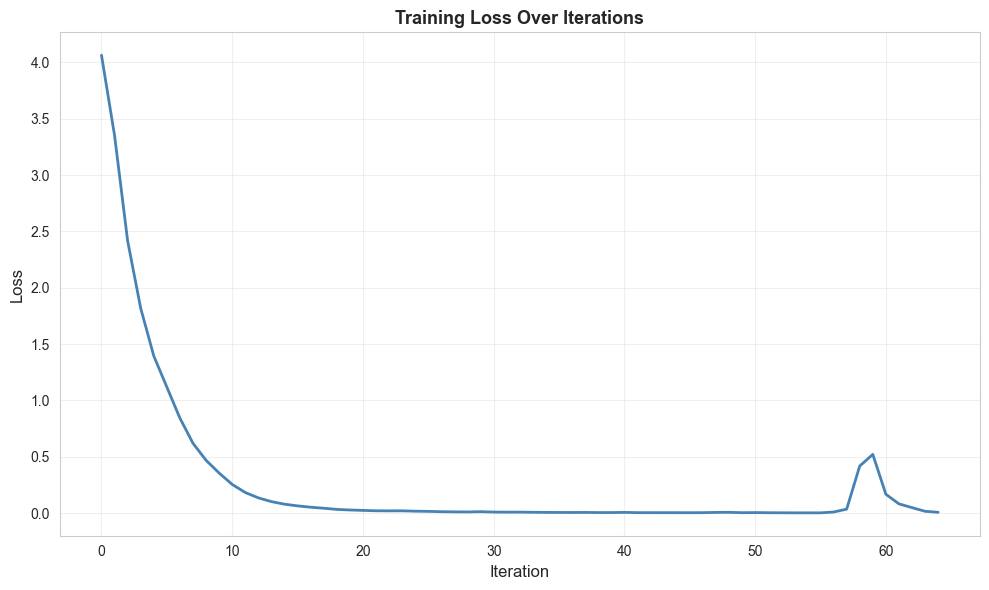

In [11]:
# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(mlp_model.loss_curve_, linewidth=2, color='steelblue')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Over Iterations', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Model Evaluation

In [12]:
# Make predictions
print("Making predictions on validation and test sets...")
y_train_pred = mlp_model.predict(X_train)
y_val_pred = mlp_model.predict(X_val)
y_test_pred = mlp_model.predict(X_test)

# Get prediction probabilities
y_train_pred_proba = mlp_model.predict_proba(X_train)
y_val_pred_proba = mlp_model.predict_proba(X_val)
y_test_pred_proba = mlp_model.predict_proba(X_test)

print("✓ Predictions completed")

Making predictions on validation and test sets...
✓ Predictions completed


In [13]:
# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name=""):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{set_name} Performance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return accuracy, precision, recall, f1

print("=" * 60)
print(f"MODEL PERFORMANCE METRICS")
print("=" * 60)

train_acc, train_prec, train_rec, train_f1 = calculate_metrics(y_train, y_train_pred, "TRAINING SET")
val_acc, val_prec, val_rec, val_f1 = calculate_metrics(y_val, y_val_pred, "VALIDATION SET")
test_acc, test_prec, test_rec, test_f1 = calculate_metrics(y_test, y_test_pred, "TEST SET")

print("\n" + "=" * 60)

MODEL PERFORMANCE METRICS

TRAINING SET Performance Metrics:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

VALIDATION SET Performance Metrics:
  Accuracy:  0.4658
  Precision: 0.4838
  Recall:    0.4658
  F1-Score:  0.4573

TEST SET Performance Metrics:
  Accuracy:  0.4609
  Precision: 0.4822
  Recall:    0.4609
  F1-Score:  0.4550



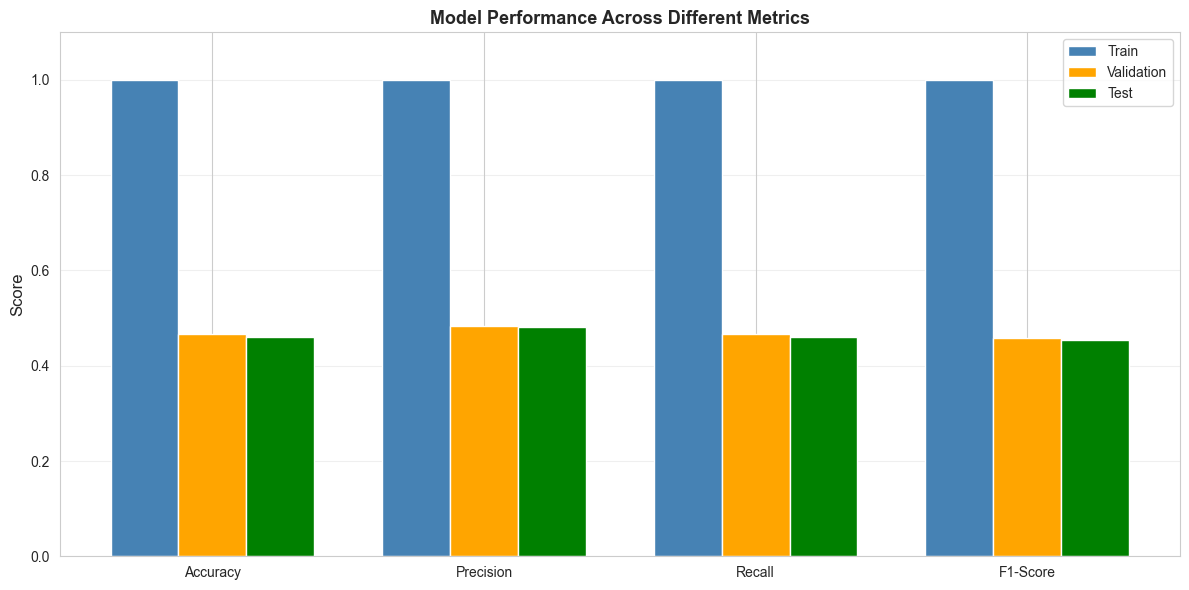

In [14]:
# Comparison plot
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Train': [train_acc, train_prec, train_rec, train_f1],
    'Validation': [val_acc, val_prec, val_rec, val_f1],
    'Test': [test_acc, test_prec, test_rec, test_f1]
}

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_data['Metric']))
width = 0.25

ax.bar(x - width, metrics_data['Train'], width, label='Train', color='steelblue')
ax.bar(x, metrics_data['Validation'], width, label='Validation', color='orange')
ax.bar(x + width, metrics_data['Test'], width, label='Test', color='green')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Across Different Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_data['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

In [15]:
# Detailed Classification Report for Test Set
print("\nDetailed Classification Report - TEST SET:")
print("=" * 60)
print(classification_report(y_test, y_test_pred, 
                          target_names=[f"Class {i}" for i in np.unique(y_test)]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix shape: {cm.shape}")


Detailed Classification Report - TEST SET:
              precision    recall  f1-score   support

     Class 0       0.08      0.12      0.10         8
     Class 1       0.44      0.50      0.47         8
     Class 2       0.56      0.62      0.59         8
     Class 3       0.50      0.38      0.43         8
     Class 4       0.57      0.50      0.53         8
     Class 5       0.50      0.12      0.20         8
     Class 6       0.40      0.50      0.44         8
     Class 7       0.50      0.56      0.53         9
     Class 8       0.70      0.88      0.78         8
     Class 9       0.33      0.50      0.40         8
    Class 10       0.78      0.88      0.82         8
    Class 11       0.43      0.67      0.52         9
    Class 12       0.55      0.75      0.63         8
    Class 13       0.40      0.25      0.31         8
    Class 14       0.38      0.38      0.38         8
    Class 15       0.71      0.62      0.67         8
    Class 16       0.80      0.50    

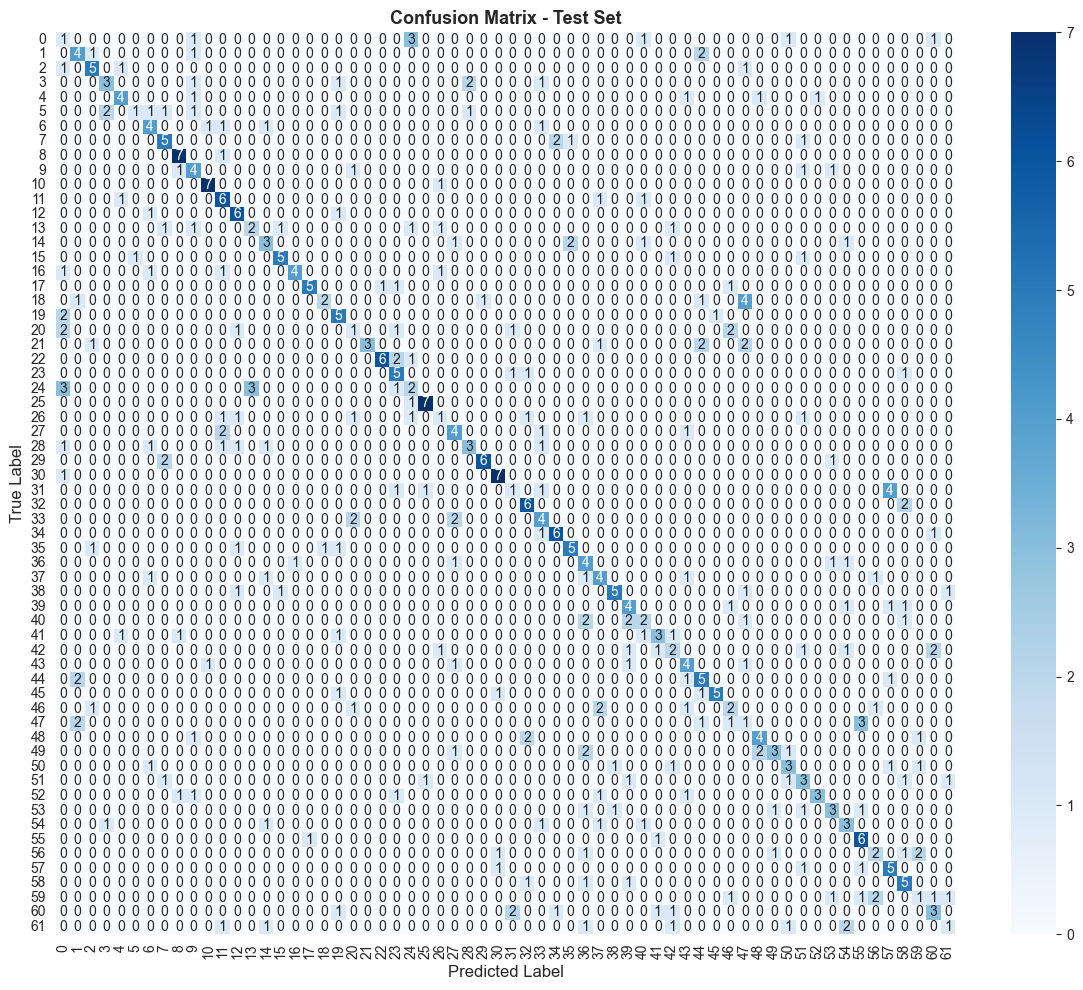

In [16]:
# Visualize Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Predictions on New Data

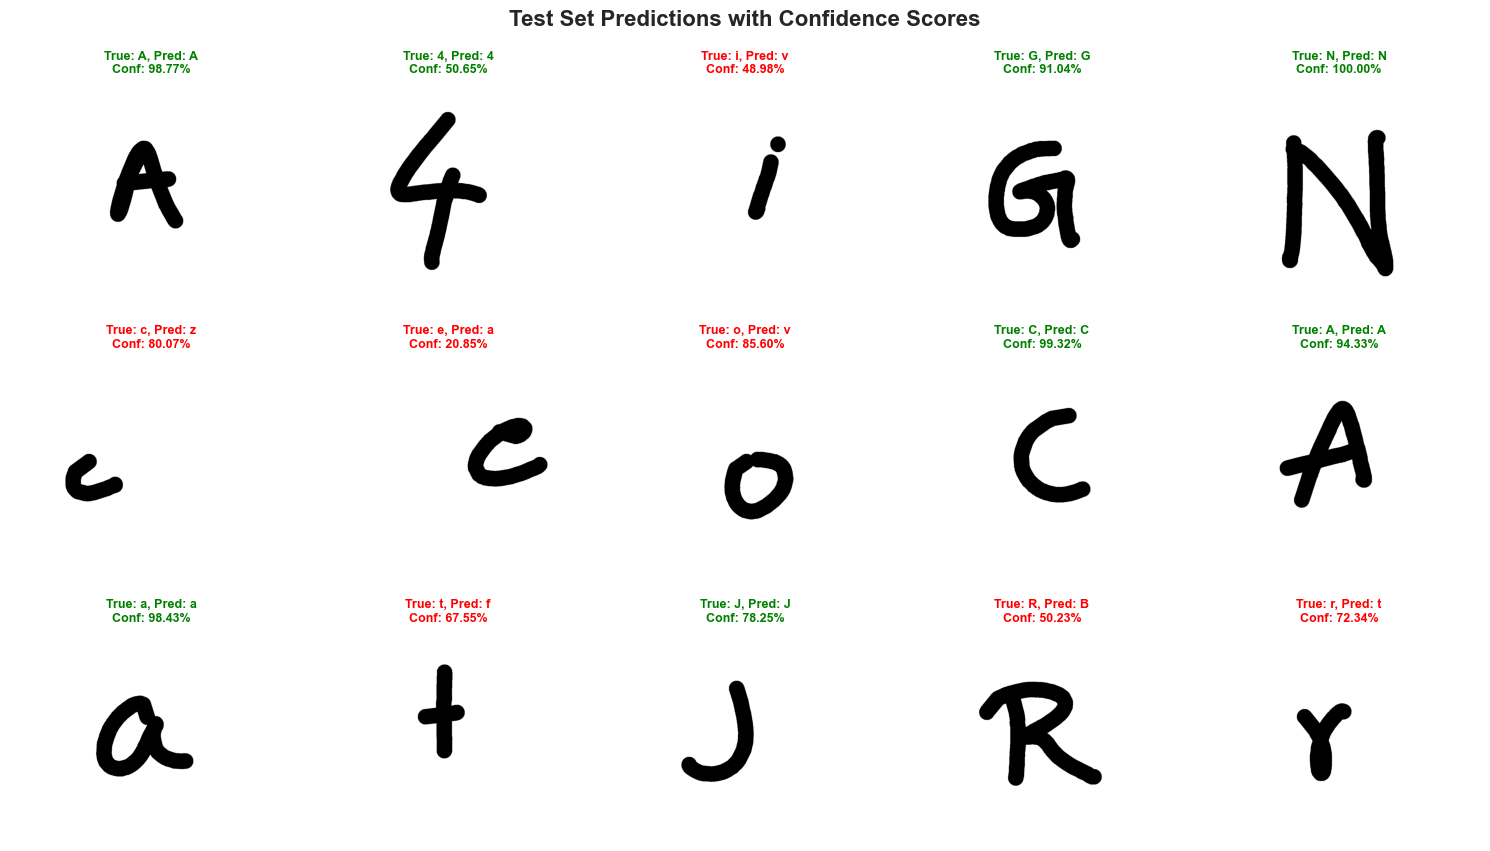

In [17]:
# Make predictions on test samples with confidence scores
num_samples = 15
test_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Test Set Predictions with Confidence Scores', fontsize=16, fontweight='bold')

for idx, test_pos in enumerate(test_indices):
    ax = axes[idx // 5, idx % 5]

    data_idx = idx_test[test_pos]
    img_path = os.path.join('../data/', df.iloc[data_idx]['image'])
    img = Image.open(img_path).convert('L')
    img_display = np.array(img)

    true_label = le.inverse_transform([y_test[test_pos]])[0]
    pred_label = le.inverse_transform([y_test_pred[test_pos]])[0]
    confidence = y_test_pred_proba[test_pos].max()

    color = 'green' if true_label == pred_label else 'red'

    ax.imshow(img_display, cmap='gray')
    ax.set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.2%}',
                fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

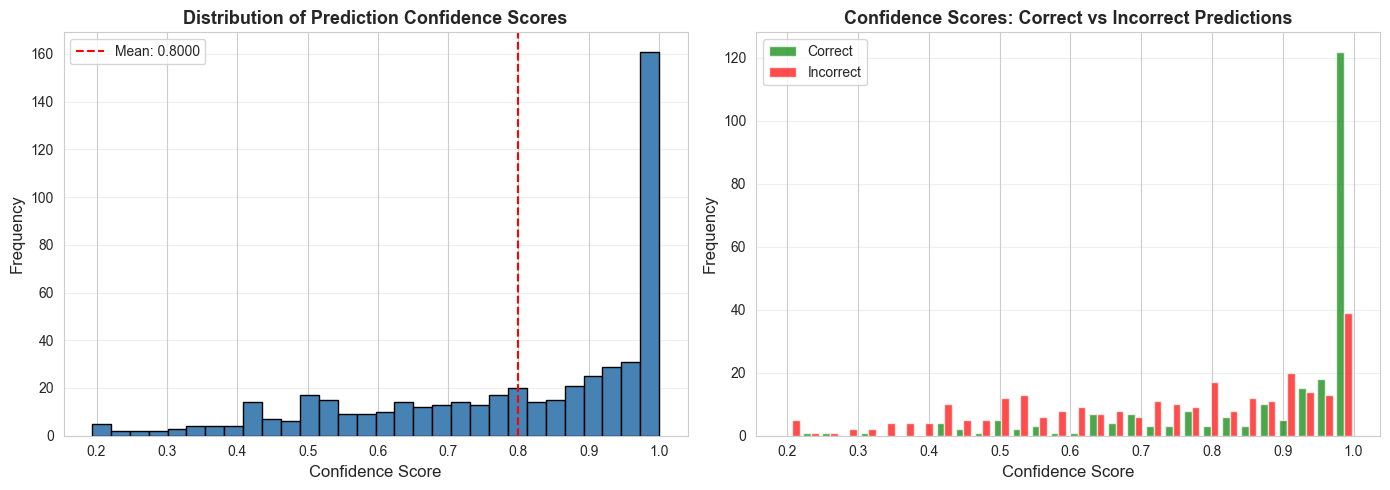


Confidence Score Statistics:
  Mean: 0.8000
  Median: 0.8803
  Min: 0.1934
  Max: 1.0000
  Std Dev: 0.2098


In [18]:
# Analyze prediction confidence distribution
confidence_scores = y_test_pred_proba.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence scores
axes[0].hist(confidence_scores, bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Confidence Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Confidence Scores', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(confidence_scores.mean(), color='red', linestyle='--', 
                label=f'Mean: {confidence_scores.mean():.4f}')
axes[0].legend()

# Correct vs Incorrect predictions
correct = y_test == y_test_pred
axes[1].hist([confidence_scores[correct], confidence_scores[~correct]], 
             bins=30, label=['Correct', 'Incorrect'], color=['green', 'red'], alpha=0.7)
axes[1].set_xlabel('Confidence Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Confidence Scores: Correct vs Incorrect Predictions', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConfidence Score Statistics:")
print(f"  Mean: {confidence_scores.mean():.4f}")
print(f"  Median: {np.median(confidence_scores):.4f}")
print(f"  Min: {confidence_scores.min():.4f}")
print(f"  Max: {confidence_scores.max():.4f}")
print(f"  Std Dev: {confidence_scores.std():.4f}")

## Step 8: Model Summary and Analysis

In [19]:
print("\n" + "=" * 70)
print("MULTILAYER PERCEPTRON - CHARACTER RECOGNITION MODEL SUMMARY")
print("=" * 70)

print("\n📊 DATASET INFORMATION:")
print(f"  Total samples: {len(X_normalized)}")
print(f"  Training samples: {len(X_train)} (70%)")
print(f"  Validation samples: {len(X_val)} (15%)")
print(f"  Test samples: {len(X_test)} (15%)")
print(f"  Features per image: {X_train.shape[1]}")
print(f"  Number of classes: {len(np.unique(y_full))}")

print("\n🧠 MODEL ARCHITECTURE:")
print(f"  Input layer: {X_train.shape[1]} neurons")
print(f"  Hidden layer 1: 256 neurons (ReLU)")
print(f"  Hidden layer 2: 128 neurons (ReLU)")
print(f"  Hidden layer 3: 64 neurons (ReLU)")
print(f"  Output layer: {len(np.unique(y_full))} neurons (Softmax)")
print(f"  Total parameters: ~{(X_train.shape[1]*256 + 256*128 + 128*64 + 64*len(np.unique(y_full)))}")

print("\n⚙️  TRAINING CONFIGURATION:")
print(f"  Optimizer: Adam")
print(f"  Loss function: Cross-entropy")
print(f"  Learning rate: 0.001 (adaptive)")
print(f"  Batch size: 32")
print(f"  Max iterations: 300")
print(f"  Early stopping: Yes (patience=20)")
print(f"  Actual iterations: {mlp_model.n_iter_}")
print(f"  Training time: {training_time:.2f} seconds")

print("\n📈 PERFORMANCE METRICS:")
print(f"  Train Accuracy:     {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Test Accuracy:      {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\n  Test Set F1-Score: {test_f1:.4f}")
print(f"  Test Set Precision: {test_prec:.4f}")
print(f"  Test Set Recall:    {test_rec:.4f}")

print("\n✅ OBSERVATIONS:")
potential_overfitting = train_acc - test_acc
if potential_overfitting > 0.1:
    print(f"  ⚠️  Potential overfitting detected (Train-Test diff: {potential_overfitting:.4f})")
else:
    print(f"  ✓ Model generalization appears good (Train-Test diff: {potential_overfitting:.4f})")

if val_acc >= 0.90:
    print(f"  ✓ Excellent validation performance")
elif val_acc >= 0.80:
    print(f"  ✓ Good validation performance")
else:
    print(f"  ⚠️  Validation performance could be improved")

print("\n" + "=" * 70)


MULTILAYER PERCEPTRON - CHARACTER RECOGNITION MODEL SUMMARY

📊 DATASET INFORMATION:
  Total samples: 3410
  Training samples: 2387 (70%)
  Validation samples: 511 (15%)
  Test samples: 512 (15%)
  Features per image: 64
  Number of classes: 62

🧠 MODEL ARCHITECTURE:
  Input layer: 64 neurons
  Hidden layer 1: 256 neurons (ReLU)
  Hidden layer 2: 128 neurons (ReLU)
  Hidden layer 3: 64 neurons (ReLU)
  Output layer: 62 neurons (Softmax)
  Total parameters: ~61312

⚙️  TRAINING CONFIGURATION:
  Optimizer: Adam
  Loss function: Cross-entropy
  Learning rate: 0.001 (adaptive)
  Batch size: 32
  Max iterations: 300
  Early stopping: Yes (patience=20)
  Actual iterations: 65
  Training time: 18.16 seconds

📈 PERFORMANCE METRICS:
  Train Accuracy:     1.0000 (100.00%)
  Validation Accuracy: 0.4658 (46.58%)
  Test Accuracy:      0.4609 (46.09%)

  Test Set F1-Score: 0.4550
  Test Set Precision: 0.4822
  Test Set Recall:    0.4609

✅ OBSERVATIONS:
  ⚠️  Potential overfitting detected (Train-Te

In [20]:
# Save model bundle
import joblib

bundle = {
    'model': mlp_model,
    'pca': pca,
    'scaler': scaler,
    'label_encoder': le
}

bundle_path = 'mlp_character_recognition_bundle.pkl'
joblib.dump(bundle, bundle_path)

print(f"Model bundle saved to: {bundle_path}")

Model bundle saved to: mlp_character_recognition_bundle.pkl


## Step 9: Function for Predicting on Custom Images

In [ ]:
def predict_character(image_path, model=mlp_model, return_top_k=3):
    """
    Predict character class from an image file
    
    Args:
        image_path: Path to image file
        model: Trained MLP model
        return_top_k: Return top K predictions
        
    Returns:
        Dictionary with prediction results
    """
    try:
        img = Image.open(image_path).convert('L')
        
        # Calculate expected image size based on PCA's n_features_in_
        expected_features = pca.n_features_in_
        expected_size = int(np.sqrt(expected_features))
        
        # Resize image to match PCA training dimensions
        img = img.resize((expected_size, expected_size), Image.Resampling.LANCZOS)
        
        img_array = np.array(img, dtype=np.float32).flatten()
        img_array /= 255.0

        img_pca = pca.transform(img_array.reshape(1, -1))
        img_scaled = scaler.transform(img_pca)

        prediction = model.predict(img_scaled)[0]
        probabilities = model.predict_proba(img_scaled)[0]

        top_k_indices = np.argsort(probabilities)[-return_top_k:][::-1]
        top_k_predictions = [(le.inverse_transform([idx])[0], probabilities[idx]) for idx in top_k_indices]

        return {
            'image_path': image_path,
            'predicted_class': le.inverse_transform([prediction])[0],
            'confidence': probabilities[prediction],
            'top_k_predictions': top_k_predictions,
            'all_probabilities': probabilities
        }
    except Exception as e:
        return {'error': str(e)}

Example Prediction:
  True label: O
  Predicted label: D
  Confidence: 0.4163 (41.63%)
  Correct: No
